# Robust Recourse Under Missingness

## Setup

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data        import load_diabetes, train_test_split
from model       import train, compute_hessian, predict, score
from imputer     import fit_mice, get_imputation_params
from beam_search import beam_search
from evaluate    import random_retrain_validity, rashomon_dropout_validity, awp_validity

%matplotlib inline

## Data

In [61]:
X, Xi, y, Phi, feature_names, col_means, col_stds = load_diabetes()
train_idx, test_idx = train_test_split(len(y))

X_train, Xi_train = X[train_idx], Xi[train_idx]
X_test,  Xi_test  = X[test_idx],  Xi[test_idx]
Phi_train, y_train = Phi[train_idx], y[train_idx]
Phi_test,  y_test  = Phi[test_idx],  y[test_idx]

n=768  d=8  diabetic=268  not=500
  Glucose                          5 missing (0.7%)
  BloodPressure                   35 missing (4.6%)
  SkinThickness                  227 missing (29.6%)
  Insulin                        374 missing (48.7%)
  BMI                             11 missing (1.4%)


## Model

In [62]:
theta_hat, model = train(Phi_train, y_train)
hessian_matrix   = compute_hessian(Phi_train, theta_hat)

train_acc = (predict(Phi_train, theta_hat) == y_train).mean()
test_acc  = (predict(Phi_test,  theta_hat) == y_test).mean()
print(f"train acc: {train_acc:.3f}  test acc: {test_acc:.3f}")
print(f"hessian min eigenvalue: {np.linalg.eigvalsh(hessian_matrix).min():.6f}")

train acc: 0.774  test acc: 0.765
hessian min eigenvalue: 0.001000


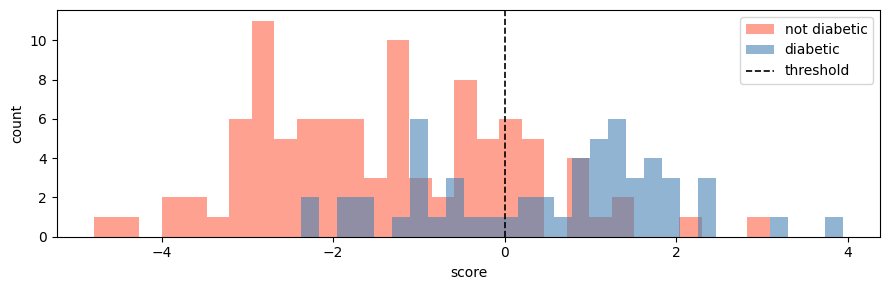

In [63]:
# score distribution by class
test_scores = score(Phi_test, theta_hat)

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(test_scores[y_test == -1], bins=30, alpha=0.6, color='tomato',    label='not diabetic')
ax.hist(test_scores[y_test ==  1], bins=30, alpha=0.6, color='steelblue', label='diabetic')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold')
ax.set_xlabel("score")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## Imputer

In [64]:
mice_imputer = fit_mice(X_train, Xi_train)

## Pick a denied person

In [65]:
test_preds   = predict(Phi_test, theta_hat)
denied_idx   = test_idx[test_preds == -1]

# find a denied person with missing features
denied_with_missing = [i for i in denied_idx if Xi[i].sum() > 0]
person_idx = denied_with_missing[0]

x0   = X[person_idx]
xi0  = Xi[person_idx]
raw_score = score(Phi[[person_idx]], theta_hat)[0]

print(f"person {person_idx}  |  score: {raw_score:.4f}  (needs >= 0)")
print(f"missing: {[feature_names[j] for j in np.where(xi0 == 1)[0]] or 'none'}")
print()
for j, name in enumerate(feature_names):
    status = ' [missing]' if xi0[j] == 1 else ''
    print(f"  {name:<30} {x0[j]:>7.3f}{status}")

person 324  |  score: -1.3468  (needs >= 0)
missing: ['Insulin']

  Pregnancies                     -0.548
  Glucose                         -0.317
  BloodPressure                    0.210
  SkinThickness                    0.272
  Insulin                          0.000 [missing]
  BMI                              0.469
  DiabetesPedigreeFunction        -0.978
  Age                             -1.042


## Recourse

In [66]:
# hyperparameters
epsilon     = 0.001   # rashomon radius — how conservative about model uncertainty
rho         = 1.0     # imputation ellipsoid radius — how conservative about missing values
kappa_val   = 0.5     # cost to reveal a feature
beam_width  = 3
K_max       = 3       # max features we can reveal
K_mice      = 100     # mice draws for imputation ellipsoid

kappa  = np.ones(len(x0)) * kappa_val
J_edit = list(range(len(x0)))

In [67]:
best_r, best_delta, best_cost, history = beam_search(
    x0, xi0,
    theta_hat, hessian_matrix,
    mice_imputer,
    epsilon    = epsilon,
    rho        = rho,
    kappa      = kappa,
    J_edit     = J_edit,
    tau        = 0.0,
    beam_width = beam_width,
    K_max      = K_max,
    K_mice     = K_mice,
    verbose    = True,
)


step 0: 1 candidate(s)
  r=[0, 0, 0, 0, 0, 0, 0, 0]  cost=1.4062

step 1: 1 candidate(s)
  r=[0, 0, 0, 0, 1, 0, 0, 0]  cost=2.0164
no more features to reveal


## Result

In [68]:
if best_r is None:
    print("no feasible recourse found — try increasing K_max or decreasing epsilon")
else:
    print(f"total cost: {best_cost:.4f}")
    print(f"reveal    : {[feature_names[j] for j in np.where(best_r == 1)[0]] or 'nothing'}")
    print()
    print(f"{'feature':<30} {'from':>8} {'to':>8} {'change':>8}")
    print('-' * 56)
    for j in range(len(x0)):
        if abs(best_delta[j]) > 1e-4:
            old, new = x0[j], x0[j] + best_delta[j]
            print(f"{feature_names[j]:<30} {old:>8.3f} {new:>8.3f} {new-old:>+8.3f}")

total cost: 1.4062
reveal    : nothing

feature                            from       to   change
--------------------------------------------------------
Pregnancies                      -0.548   -0.325   +0.223
Glucose                          -0.317    0.793   +1.110
BloodPressure                     0.210    0.038   -0.172
SkinThickness                     0.272    0.375   +0.103
BMI                               0.469    1.123   +0.655
DiabetesPedigreeFunction         -0.978   -0.724   +0.254
Age                              -1.042   -0.640   +0.402


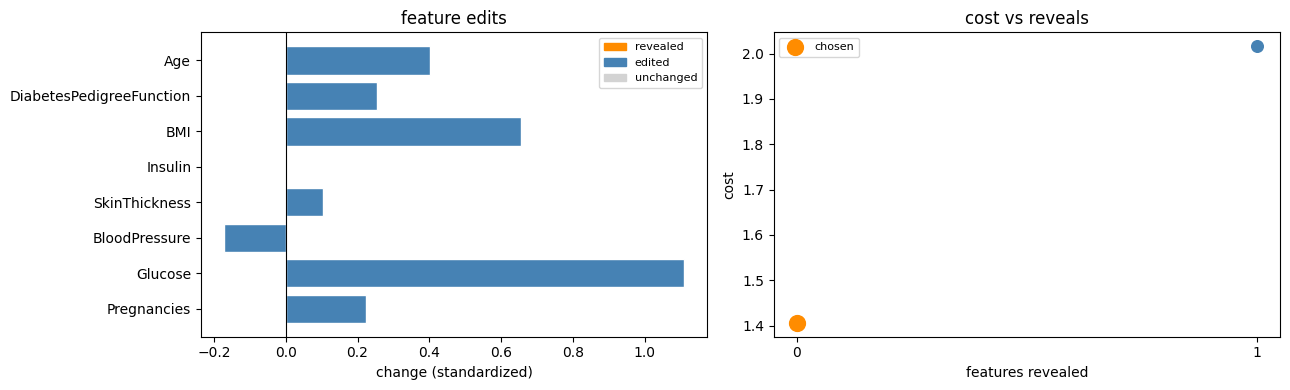

In [69]:
if best_r is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # feature changes
    ax = axes[0]
    colors = ['darkorange' if best_r[j] == 1
              else 'steelblue' if abs(best_delta[j]) > 1e-4
              else 'lightgrey'
              for j in range(len(feature_names))]
    ax.barh(feature_names, best_delta, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel("change (standardized)")
    ax.set_title("feature edits")
    ax.legend(handles=[
        mpatches.Patch(color='darkorange', label='revealed'),
        mpatches.Patch(color='steelblue',  label='edited'),
        mpatches.Patch(color='lightgrey',  label='unchanged'),
    ], fontsize=8)

    # cost vs reveals
    ax2 = axes[1]
    feasible = [h for h in history if h['feasible']]
    if feasible:
        n_reveals = [int(h['r'].sum()) for h in feasible]
        costs     = [h['cost'] for h in feasible]
        ax2.scatter(n_reveals, costs, s=70, color='steelblue', zorder=3)
        ax2.scatter([int(best_r.sum())], [best_cost], s=130, color='darkorange',
                    zorder=4, label='chosen')
        ax2.set_xlabel("features revealed")
        ax2.set_ylabel("cost")
        ax2.set_title("cost vs reveals")
        ax2.set_xticks(sorted(set(n_reveals)))
        ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## Sensitivity to epsilon

epsilon=0.0001  cost=1.1349
epsilon=0.0005  cost=1.2956
epsilon=0.0010  cost=1.4181
epsilon=0.0050  cost=1.9672
epsilon=0.0100  cost=2.4303
epsilon=0.0500  cost=4.1843


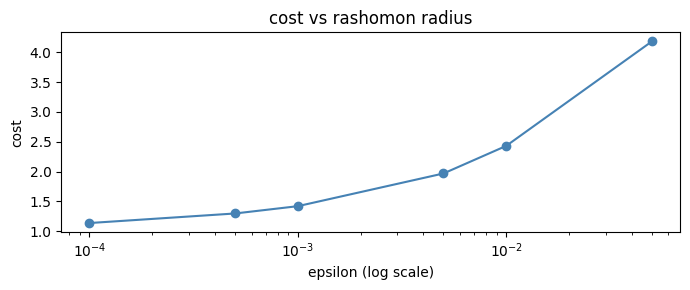

In [70]:
epsilons = [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.05]
costs    = []

for eps in epsilons:
    _, _, cost, _ = beam_search(
        x0, xi0, theta_hat, hessian_matrix, mice_imputer,
        epsilon=eps, rho=rho, kappa=kappa, J_edit=J_edit,
        tau=0.0, beam_width=3, K_max=3, K_mice=50, verbose=False,
    )
    costs.append(cost)
    status = f"cost={cost:.4f}" if cost < np.inf else "infeasible"
    print(f"epsilon={eps:.4f}  {status}")

fig, ax = plt.subplots(figsize=(7, 3))
feasible_eps   = [e for e, c in zip(epsilons, costs) if c < np.inf]
feasible_costs = [c for c in costs if c < np.inf]
ax.plot(feasible_eps, feasible_costs, 'o-', color='steelblue')
ax.set_xscale('log')
ax.set_xlabel("epsilon (log scale)")
ax.set_ylabel("cost")
ax.set_title("cost vs rashomon radius")
plt.tight_layout()
plt.show()

## Evaluation

In [71]:
# single-person evaluation (uses the person from the Recourse section above)
if best_r is not None:
    xi_c_eval = xi0 - best_r
    mu_eval, _, _ = get_imputation_params(mice_imputer, x0, xi_c_eval, K=100)

    rr = random_retrain_validity(
        X_train, Xi_train, y_train,
        x0, best_delta, xi0, best_r, mu_eval,
        n_models=50,
    )
    rd = rashomon_dropout_validity(
        theta_hat, x0, best_delta, xi0, best_r, mu_eval,
        dropout_rate=0.1, n_samples=200,
    )
    awp, score_adv = awp_validity(
        theta_hat, hessian_matrix,
        x0, best_delta, xi0, best_r, mu_eval,
        epsilon=epsilon,
    )

    print(f"person {person_idx}  |  recourse cost: {best_cost:.4f}")
    print(f"  random retrain validity   : {rr:.3f}  (50 bootstrap retrains)")
    print(f"  rashomon dropout validity : {rd:.3f}  (200 dropout masks, rate=0.1)")
    print(f"  awp passes                : {awp}  (adversarial score={score_adv:.4f})")
else:
    print("no feasible recourse — skip evaluation")

person 324  |  recourse cost: 1.4062
  random retrain validity   : 0.980  (50 bootstrap retrains)
  rashomon dropout validity : 0.835  (200 dropout masks, rate=0.1)
  awp passes                : True  (adversarial score=0.3494)


### Batch evaluation — all denied test persons with missing features

denied test persons with missing features: 53

feasibility rate : 53/53 = 1.000
random retrain   : mean=0.972  min=0.900  max=1.000
rashomon dropout : mean=0.905  min=0.835  max=0.990
awp pass rate    : 1.000  (53/53 pass)


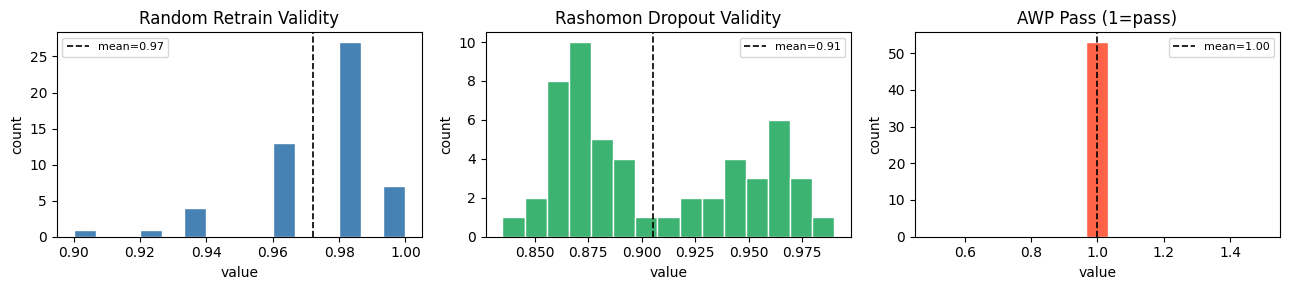

In [72]:
batch_results = []

denied_all = [i for i in test_idx if predict(Phi[[i]], theta_hat)[0] == -1 and Xi[i].sum() > 0]
print(f"denied test persons with missing features: {len(denied_all)}")

for idx in denied_all:
    x0_b, xi0_b = X[idx], Xi[idx]

    r_b, delta_b, cost_b, _ = beam_search(
        x0_b, xi0_b,
        theta_hat, hessian_matrix,
        mice_imputer,
        epsilon    = epsilon,
        rho        = rho,
        kappa      = kappa,
        J_edit     = J_edit,
        tau        = 0.0,
        beam_width = beam_width,
        K_max      = K_max,
        K_mice     = K_mice,
        verbose    = False,
    )

    if r_b is None:
        batch_results.append({"idx": idx, "feasible": False,
                               "rr": None, "rd": None, "awp": None})
        continue

    xi_c_b = xi0_b - r_b
    mu_b, _, _ = get_imputation_params(mice_imputer, x0_b, xi_c_b, K=100)

    rr_b = random_retrain_validity(
        X_train, Xi_train, y_train,
        x0_b, delta_b, xi0_b, r_b, mu_b, n_models=50,
    )
    rd_b = rashomon_dropout_validity(
        theta_hat, x0_b, delta_b, xi0_b, r_b, mu_b,
        dropout_rate=0.1, n_samples=200,
    )
    awp_b, _ = awp_validity(
        theta_hat, hessian_matrix,
        x0_b, delta_b, xi0_b, r_b, mu_b,
        epsilon=epsilon,
    )

    batch_results.append({"idx": idx, "feasible": True, "cost": cost_b,
                           "rr": rr_b, "rd": rd_b, "awp": awp_b})

# ── summary ──────────────────────────────────────────────────────────────────
feasible = [r for r in batch_results if r["feasible"]]
n_total   = len(batch_results)
n_feas    = len(feasible)

print(f"\nfeasibility rate : {n_feas}/{n_total} = {n_feas/n_total:.3f}")

if n_feas > 0:
    rr_vals  = [r["rr"]  for r in feasible]
    rd_vals  = [r["rd"]  for r in feasible]
    awp_vals = [r["awp"] for r in feasible]

    print(f"random retrain   : mean={np.mean(rr_vals):.3f}  min={np.min(rr_vals):.3f}  max={np.max(rr_vals):.3f}")
    print(f"rashomon dropout : mean={np.mean(rd_vals):.3f}  min={np.min(rd_vals):.3f}  max={np.max(rd_vals):.3f}")
    print(f"awp pass rate    : {np.mean(awp_vals):.3f}  ({sum(awp_vals)}/{n_feas} pass)")

    # distribution plot
    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    for ax, vals, title, color in zip(
        axes,
        [rr_vals, rd_vals, [float(v) for v in awp_vals]],
        ["Random Retrain Validity", "Rashomon Dropout Validity", "AWP Pass (1=pass)"],
        ["steelblue", "mediumseagreen", "tomato"],
    ):
        ax.hist(vals, bins=15, color=color, edgecolor='white')
        ax.axvline(np.mean(vals), color='black', linestyle='--', linewidth=1.2,
                   label=f"mean={np.mean(vals):.2f}")
        ax.set_title(title)
        ax.set_xlabel("value")
        ax.set_ylabel("count")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()